<a href="https://colab.research.google.com/github/Sama-Elmogy/Deep-learing-neural-network-ITI-tasks-/blob/main/DAY_1_TASK_bengaluru_modeling_Sama_Ahmed_Elmogy_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q optuna hyperopt tensorflow scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 26.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import optuna

from hyperopt import fmin, tpe, hp, Trials, STATUS_OK


print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
house_df = pd.read_csv('/content/bengaluru_house_prices.csv')

In [4]:
print("\nHouse dataset:")

print(house_df.shape)

display(house_df.head())
print(house_df.info())

print(
    house_df.isnull().sum()
    .sort_values(ascending=False)
)


House dataset:
(13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB
None
society         5502
balcony          609
bath              73
size              16
location           1
area_type          0
availability       0
total_sqft         0
price              0
dtype: int64


In [5]:
print("Duplicates:", house_df.duplicated().sum())

Duplicates: 529


In [6]:
house_df = house_df.drop_duplicates().copy()
print(house_df.shape)

(12791, 9)


In [12]:
house_df["society"] = house_df["society"].fillna("Unknown")

house_df["location"] = house_df["location"].fillna("Unknown")


In [13]:
house_df["bhk"] = house_df["bhk"].fillna(
    house_df["bhk"].median()
)

In [18]:
def convert_sqft(x):
    try:
        if "-" in str(x):
            a, b = x.split("-")
            return (float(a) + float(b)) / 2
        return float(x)
    except:
        return np.nan

house_df["total_sqft"] = house_df["total_sqft"].apply(convert_sqft)

print(house_df["total_sqft"].dtype)
print("Missing:", house_df["total_sqft"].isnull().sum())

float64
Missing: 46


In [19]:
house_df["total_sqft"] = house_df["total_sqft"].fillna(
    house_df["total_sqft"].median()
)

In [20]:
house_df["bath"] = house_df["bath"].fillna(
    house_df["bath"].median()
)

In [21]:
house_df["balcony"] = house_df["balcony"].fillna(
    house_df["balcony"].median()
)

In [22]:
print(house_df.isnull().sum())

area_type       0
availability    0
location        0
society         0
total_sqft      0
bath            0
balcony         0
price           0
bhk             0
dtype: int64


In [23]:
#Remove impossible house sizes
house_df = house_df[house_df["total_sqft"] >= 300].copy()

#Remove impossible prices
house_df = house_df[house_df["price"] > 0].copy()

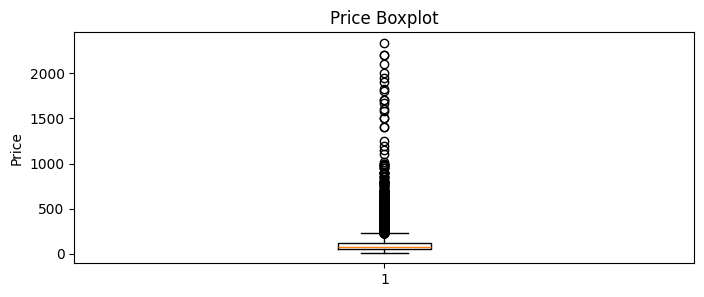

In [65]:
plt.figure(figsize=(8,3))

plt.boxplot(house_df["price"].dropna())

plt.title("Price Boxplot")
plt.ylabel("Price")

plt.show()

In [25]:
# outliers
house_df["price_per_sqft"] = (
    house_df["price"] * 100000 / house_df["total_sqft"]
)
low = house_df["price_per_sqft"].quantile(0.01)
high = house_df["price_per_sqft"].quantile(0.99)

house_df = house_df[
    house_df["price_per_sqft"].between(low, high)
].copy()


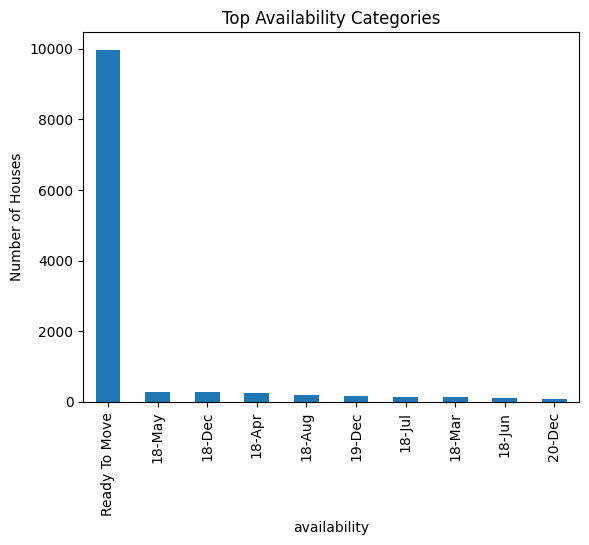

In [62]:
# checking availability
house_df["availability"].value_counts().head(10).plot(
    kind="bar",
    title="Top Availability Categories"
)

plt.ylabel("Number of Houses")
plt.show()

location
Whitefield                  518
Sarjapur  Road              376
Electronic City             274
Kanakpura Road              249
Thanisandra                 229
Yelahanka                   205
Marathahalli                169
Hebbal                      161
Raja Rajeshwari Nagar       157
Uttarahalli                 155
Bannerghatta Road           148
Hennur Road                 148
7th Phase JP Nagar          135
Electronic City Phase II    126
Rajaji Nagar                104
Name: count, dtype: int64


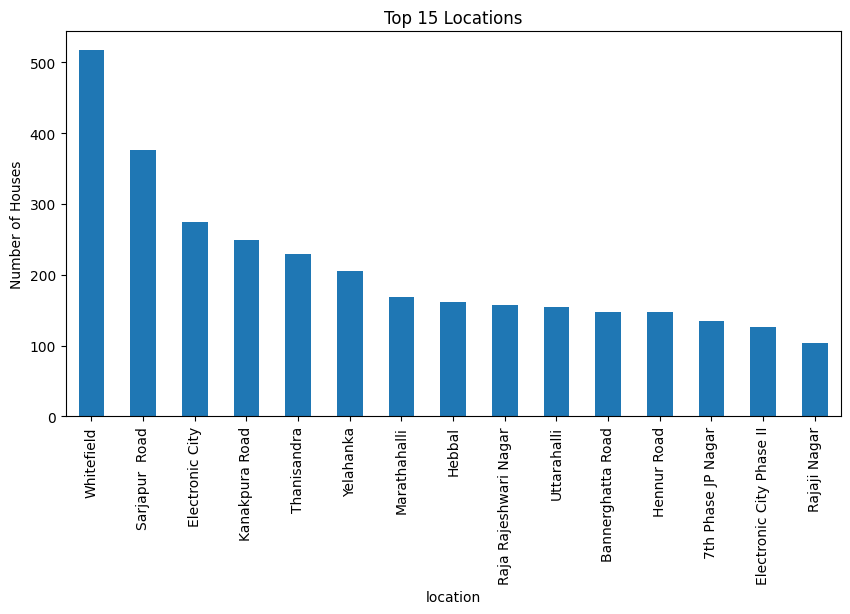

In [64]:
top_locations = house_df["location"].value_counts().head(15)
print(top_locations)
top_locations.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 15 Locations"
)

plt.ylabel("Number of Houses")
plt.show()
#location has a huge effect on house prices

#**preparing the data for the model**

In [31]:
#separate x y
X = house_df.drop(columns="price")
y = house_df["price"]


# train test validation split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.20, random_state=42
)

In [32]:
#Identify categorical and numerical columns
cat_cols = [
    "area_type", "availability", "location", "society"
]

num_cols = [
    "total_sqft", "bath", "balcony", "bhk"
]

In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), cat_cols)
])

# transform the data
X_train_p = preprocessor.fit_transform(X_train)
X_val_p = preprocessor.transform(X_val)
X_test_p = preprocessor.transform(X_test)

In [34]:
#Convert to float32 because TensorFlow works very well with it
X_train_p = X_train_p.astype("float32")
X_val_p = X_val_p.astype("float32")
X_test_p = X_test_p.astype("float32")

In [35]:
# base line model
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1)
])

#compile
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# train
early_stop = keras.callbacks.EarlyStopping(
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=150,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

# evaluate the baseline
pred = model.predict(X_test_p).flatten()
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Epoch 1/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 12732.8174 - mae: 58.3534 - val_loss: 5464.0210 - val_mae: 33.9256
Epoch 2/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4635.0898 - mae: 31.4256 - val_loss: 5382.6982 - val_mae: 33.6528
Epoch 3/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3783.7356 - mae: 27.9210 - val_loss: 4895.9009 - val_mae: 31.0738
Epoch 4/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3640.8486 - mae: 26.5808 - val_loss: 5098.1992 - val_mae: 28.7729
Epoch 5/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3105.0198 - mae: 24.5418 - val_loss: 5465.3311 - val_mae: 30.2485
Epoch 6/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2752.8550 - mae: 23.8471 - val_loss: 4597.3506 - val_mae: 29.2327
Epoch 7/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2940.0918 - mae: 23.5015 - val_loss: 4326.8164 - val_mae: 27.3914
Epoch 8/150
251/251 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 2413.4722 - mae: 22.3475 - val_loss: 4336.7656 - 

#**Hyperopt**

In [50]:
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

In [51]:
space = {
    "layers": hp.choice("layers", [2, 3, 4]),
    "units": hp.choice("units", [32, 64, 128, 256]),
    "dropout": hp.uniform("dropout", 0.0, 0.4),
    "lr": hp.loguniform("lr", np.log(1e-4), np.log(1e-2)),
    "batch_size": hp.choice("batch_size", [16, 32, 64])
}

In [52]:
def hyperopt_objective(params):

    model = keras.Sequential([
        layers.Input(shape=(X_train_p.shape[1],))
    ])

    for _ in range(params["layers"]):
        model.add(layers.Dense(params["units"], activation="relu"))
        model.add(layers.Dropout(params["dropout"]))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=params["lr"]
        ),
        loss="mse"
    )

    model.fit(
        X_train_p, y_train,
        validation_data=(X_val_p, y_val),
        epochs=60,
        batch_size=params["batch_size"],
        callbacks=[
            keras.callbacks.EarlyStopping(
                patience=8,
                restore_best_weights=True
            )
        ],
        verbose=0
    )

    pred = model.predict(
        X_val_p, verbose=0
    ).flatten()

    r2 = r2_score(y_val, pred)

    return {
        "loss": -r2,
        "status": STATUS_OK
    }

In [53]:
hyperopt_trials = Trials()

best_hyperopt = fmin(
    fn=hyperopt_objective,
    space=space,
    algo=tpe.suggest,
    max_evals=30,
    trials=hyperopt_trials,
    rstate=np.random.default_rng(42)
)

100%|██████████| 30/30 [16:49<00:00, 33.65s/trial, best loss: -0.8300203405837694]


In [54]:
print(best_hyperopt)

{'batch_size': np.int64(2), 'dropout': np.float64(0.041932246818587426), 'layers': np.int64(2), 'lr': np.float64(0.0016455260799501802), 'units': np.int64(3)}


In [55]:
best_params = {
    "layers": [2, 3, 4][best_hyperopt["layers"]],
    "units": [32, 64, 128, 256][best_hyperopt["units"]],
    "batch_size": [16, 32, 64][best_hyperopt["batch_size"]],
    "dropout": best_hyperopt["dropout"],
    "lr": best_hyperopt["lr"]
}

print(best_params)

{'layers': 4, 'units': 256, 'batch_size': 64, 'dropout': np.float64(0.041932246818587426), 'lr': np.float64(0.0016455260799501802)}


In [58]:
# build final hyperpot model
p = best_params

hyperopt_model = keras.Sequential([
    layers.Input(shape=(X_train_p.shape[1],))
])

for _ in range(p["layers"]):
    hyperopt_model.add(
        layers.Dense(p["units"], activation="relu")
    )
    hyperopt_model.add(
        layers.Dropout(p["dropout"])
    )

hyperopt_model.add(layers.Dense(1))

hyperopt_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=p["lr"]
    ),
    loss="mse",
    metrics=["mae"]
)

In [59]:
hyperopt_history = hyperopt_model.fit(
    X_train_p, y_train,
    validation_data=(X_val_p, y_val),
    epochs=150,
    batch_size=p["batch_size"],
    callbacks=[
        keras.callbacks.EarlyStopping(
            patience=15,
            restore_best_weights=True
        )
    ],
    verbose=1
)

Epoch 1/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 7770.0439 - mae: 44.3096 - val_loss: 10242.9199 - val_mae: 58.1950
Epoch 2/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4572.9790 - mae: 33.2510 - val_loss: 4259.2363 - val_mae: 29.3171
Epoch 3/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3122.7576 - mae: 27.2596 - val_loss: 4446.5562 - val_mae: 29.1520
Epoch 4/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2502.0007 - mae: 23.5454 - val_loss: 3603.1018 - val_mae: 30.4956
Epoch 5/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1782.0739 - mae: 21.3633 - val_loss: 3510.7244 - val_mae: 26.3148
Epoch 6/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1489.2712 - mae: 19.0602 - val_loss: 2871.5903 - val_mae: 24.8282
Epoch 7/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1349.7318 - mae: 17.9491 - val_loss: 3562.2529 - val_mae: 31.1471
Epoch 8/150
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 1390.6328 - mae: 19.0535 - val_loss: 2596.7151 -

In [60]:
hyperopt_pred = hyperopt_model.predict(
    X_test_p
).flatten()

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


In [61]:
hyperopt_mae = mean_absolute_error(
    y_test, hyperopt_pred
)

hyperopt_rmse = np.sqrt(
    mean_squared_error(y_test, hyperopt_pred)
)

hyperopt_r2 = r2_score(
    y_test, hyperopt_pred
)

print("MAE:", hyperopt_mae)
print("RMSE:", hyperopt_rmse)
print("R²:", hyperopt_r2)
print("R² %:", hyperopt_r2 * 100)

MAE: 22.756726092221204
RMSE: 53.56600836995655
R²: 0.8010252672782033
R² %: 80.10252672782033
